<h1 style="margin:0;color:#3776AB;">
🐍 Pythonize com Tomane | #021
</h1>

### Comparar preços no mercado com Python

#### 💡 Sabias que a embalagem mais barata por quilo pode não ser a que te faz gastar menos na compra de hoje?

#### Neste code, vou mostrar como comparar dois tamanhos de embalagem, calcular quantas precisas de comprar e ver o custo da lista toda. Os preços são apenas um exemplo em meticais; podes trocar pelos do teu mercado.

#### 1. Importar as bibliotecas

Se ainda não tens o `matplotlib`, instala no Jupyter com `%pip install matplotlib`. As outras bibliotecas já vêm com Python.

In [1]:
from math import ceil
import matplotlib.pyplot as plt


#### 2. Preparar a lista de compras

Em cada produto, indica quanto precisas e o tamanho e preço de cada embalagem. Usa a mesma unidade nas duas opções do mesmo produto.

In [2]:
produtos = [
    {"nome": "Arroz", "unidade": "kg", "preciso": 3,
     "opcoes": [(1, 110), (5, 520)]},
    {"nome": "Óleo", "unidade": "L", "preciso": 1.8,
     "opcoes": [(0.9, 145), (1.8, 270)]},
    {"nome": "Açúcar", "unidade": "kg", "preciso": 1,
     "opcoes": [(1, 95), (2, 185)]},
    {"nome": "Detergente", "unidade": "L", "preciso": 1.5,
     "opcoes": [(0.5, 75), (1, 140)]},
    {"nome": "Leite", "unidade": "L", "preciso": 2,
     "opcoes": [(1, 90), (2, 170)]},
]

orcamento = 1200  # MZN


#### 3. Comparar o custo de cada opção

O código calcula o número de embalagens inteiras necessário para atingir a quantidade desejada. Também mostra o preço por `kg` ou por `L`, mas escolhe pelo valor total a pagar nesta compra.

In [3]:
resultados = []

for produto in produtos:
    alternativas = []

    for tamanho, preco in produto["opcoes"]:
        if tamanho <= 0 or preco < 0 or produto["preciso"] <= 0:
            raise ValueError(f"Verifica os valores de {produto['nome']}")

        quantidade_embalagens = ceil(produto["preciso"] / tamanho - 1e-9)
        total = quantidade_embalagens * preco
        preco_unidade = preco / tamanho

        alternativas.append({
            "tamanho": tamanho,
            "preco": preco,
            "embalagens": quantidade_embalagens,
            "total": total,
            "preco_unidade": preco_unidade,
        })

    melhor = min(alternativas, key=lambda item: (item["total"],
                                                 item["embalagens"] * item["tamanho"]))
    resultados.append({**produto, "alternativas": alternativas, "melhor": melhor})

    print(f"\n{produto['nome']} — preciso de {produto['preciso']:g} {produto['unidade']}")
    for opcao in alternativas:
        print(f"  {opcao['embalagens']} × {opcao['tamanho']:g} {produto['unidade']}"
              f" → {opcao['total']:.0f} MZN"
              f" ({opcao['preco_unidade']:.0f} MZN/{produto['unidade']})")
    print(f"  Escolha para esta compra: {melhor['embalagens']} embalagem(ns)"
          f" de {melhor['tamanho']:g} {produto['unidade']}")



Arroz — preciso de 3 kg
  3 × 1 kg → 330 MZN (110 MZN/kg)
  1 × 5 kg → 520 MZN (104 MZN/kg)
  Escolha para esta compra: 3 embalagem(ns) de 1 kg

Óleo — preciso de 1.8 L
  2 × 0.9 L → 290 MZN (161 MZN/L)
  1 × 1.8 L → 270 MZN (150 MZN/L)
  Escolha para esta compra: 1 embalagem(ns) de 1.8 L

Açúcar — preciso de 1 kg
  1 × 1 kg → 95 MZN (95 MZN/kg)
  1 × 2 kg → 185 MZN (92 MZN/kg)
  Escolha para esta compra: 1 embalagem(ns) de 1 kg

Detergente — preciso de 1.5 L
  3 × 0.5 L → 225 MZN (150 MZN/L)
  2 × 1 L → 280 MZN (140 MZN/L)
  Escolha para esta compra: 3 embalagem(ns) de 0.5 L

Leite — preciso de 2 L
  2 × 1 L → 180 MZN (90 MZN/L)
  1 × 2 L → 170 MZN (85 MZN/L)
  Escolha para esta compra: 1 embalagem(ns) de 2 L


#### 4. Somar a lista e comparar com o orçamento

In [4]:
total_lista = sum(item["melhor"]["total"] for item in resultados)
saldo = orcamento - total_lista

print(f"Total da lista: {total_lista:.0f} MZN")
print(f"Orçamento: {orcamento:.0f} MZN")
print(f"Saldo: {saldo:+.0f} MZN")


Total da lista: 1090 MZN
Orçamento: 1200 MZN
Saldo: +110 MZN


#### 5. Criar os gráficos

O primeiro gráfico compara o custo das duas embalagens para a quantidade de que precisas. O segundo mostra a lista, e o terceiro acompanha o total da compra até ao orçamento.

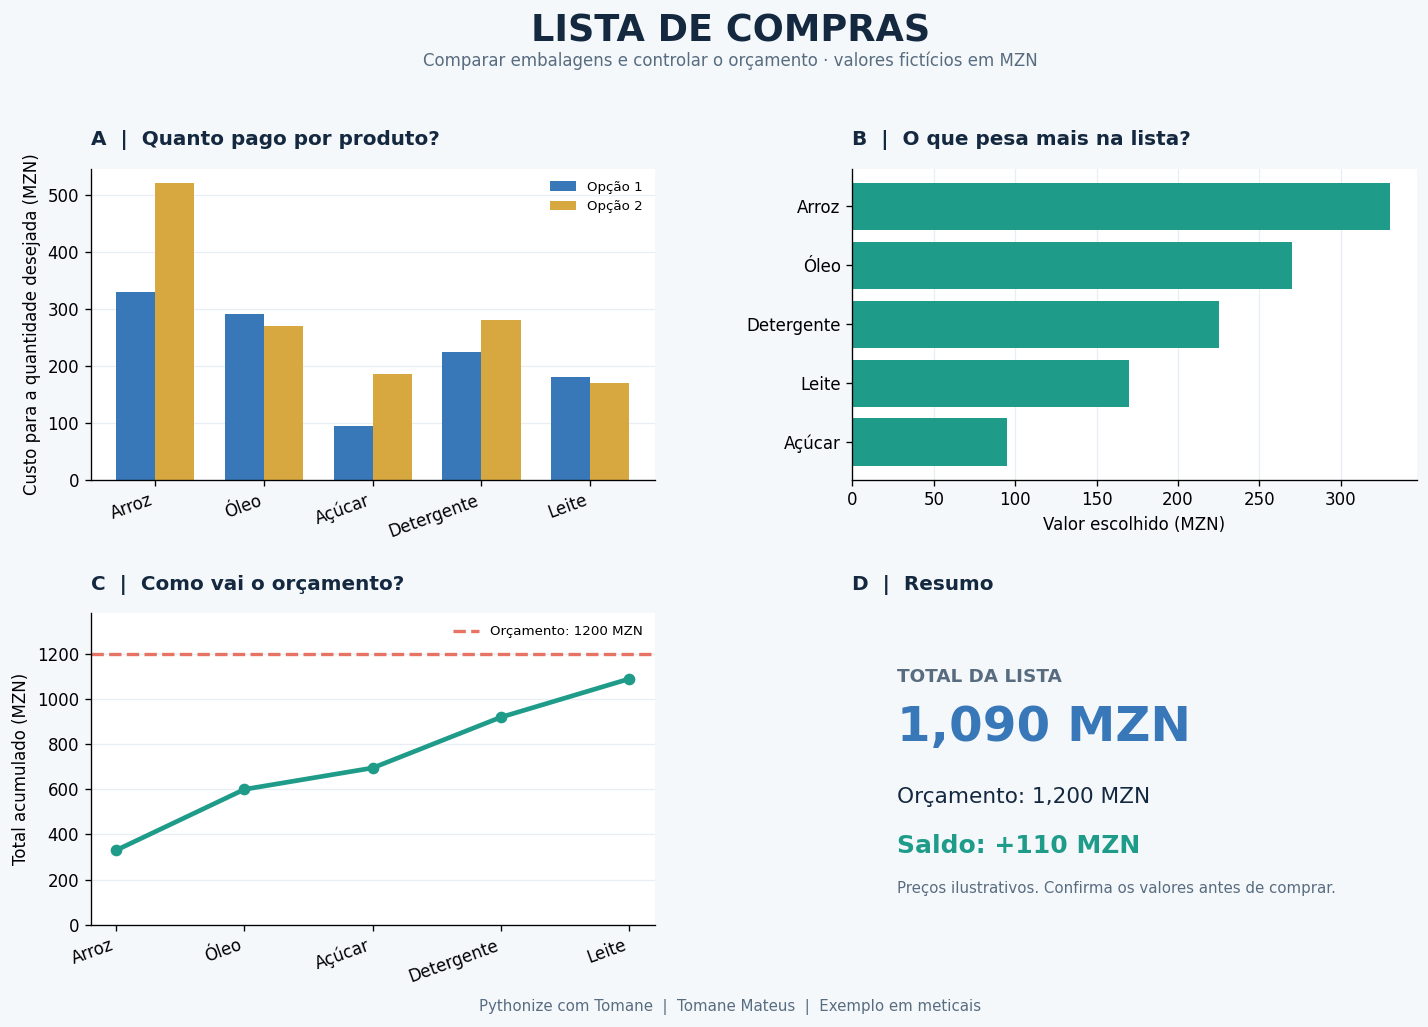

In [5]:
AZUL = "#3878B8"
VERDE = "#1E9C89"
CORAL = "#E67363"
DOURADO = "#D7A83F"
ESCURO = "#14283F"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "figure.facecolor": "#F5F8FB",
    "savefig.facecolor": "#F5F8FB",
})

nomes = [item["nome"] for item in resultados]
opcao_1 = [item["alternativas"][0]["total"] for item in resultados]
opcao_2 = [item["alternativas"][1]["total"] for item in resultados]
escolhidos = [item["melhor"]["total"] for item in resultados]
acumulado = []
soma = 0
for valor in escolhidos:
    soma += valor
    acumulado.append(soma)

fig, axs = plt.subplots(2, 2, figsize=(13, 9))
fig.subplots_adjust(left=0.09, right=0.94, top=0.83,
                    bottom=0.13, wspace=0.35, hspace=0.43)
fig.suptitle("LISTA DE COMPRAS", y=0.975, fontsize=22,
             fontweight="bold", color=ESCURO)
fig.text(0.5, 0.925, "Comparar embalagens e controlar o orçamento · valores fictícios em MZN",
         ha="center", color="#586C80")

def preparar(ax, titulo):
    ax.set_facecolor("white")
    ax.set_title(titulo, loc="left", pad=14, fontweight="bold", color=ESCURO)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#E8EEF4", linewidth=0.8)
    ax.set_axisbelow(True)

# A — Custo das opções para a quantidade necessária
ax = axs[0, 0]
preparar(ax, "A  |  Quanto pago por produto?")
x = range(len(nomes))
ax.bar([i - 0.18 for i in x], opcao_1, 0.36, color=AZUL, label="Opção 1")
ax.bar([i + 0.18 for i in x], opcao_2, 0.36, color=DOURADO, label="Opção 2")
ax.set_xticks(list(x), nomes, rotation=20, ha="right")
ax.set_ylabel("Custo para a quantidade desejada (MZN)")
ax.legend(frameon=False, fontsize=8)

# B — Valor escolhido de cada produto
ax = axs[0, 1]
preparar(ax, "B  |  O que pesa mais na lista?")
ordem = sorted(range(len(nomes)), key=lambda i: escolhidos[i])
ax.barh([nomes[i] for i in ordem], [escolhidos[i] for i in ordem], color=VERDE)
ax.set_xlabel("Valor escolhido (MZN)")
ax.grid(axis="x", color="#E8EEF4")
ax.grid(axis="y", visible=False)

# C — Total acumulado e limite do orçamento
ax = axs[1, 0]
preparar(ax, "C  |  Como vai o orçamento?")
ax.plot(range(len(nomes)), acumulado, color=VERDE, marker="o", linewidth=2.8)
ax.axhline(orcamento, color=CORAL, linestyle="--", linewidth=2,
           label=f"Orçamento: {orcamento:.0f} MZN")
ax.set_xticks(range(len(nomes)), nomes, rotation=20, ha="right")
ax.set_ylabel("Total acumulado (MZN)")
ax.set_ylim(0, max(orcamento, total_lista) * 1.15)
ax.legend(frameon=False, fontsize=8)

# D — Resumo simples da compra
ax = axs[1, 1]
ax.set_facecolor("white")
ax.set_title("D  |  Resumo", loc="left", pad=14,
             fontweight="bold", color=ESCURO)
ax.axis("off")
ax.text(0.08, 0.78, "TOTAL DA LISTA", transform=ax.transAxes,
        fontsize=11, fontweight="bold", color="#586C80")
ax.text(0.08, 0.59, f"{total_lista:,.0f} MZN", transform=ax.transAxes,
        fontsize=29, fontweight="bold", color=AZUL)
ax.text(0.08, 0.39, f"Orçamento: {orcamento:,.0f} MZN", transform=ax.transAxes,
        fontsize=13, color=ESCURO)
ax.text(0.08, 0.23, f"Saldo: {saldo:+,.0f} MZN", transform=ax.transAxes,
        fontsize=15, fontweight="bold", color=VERDE if saldo >= 0 else CORAL)
ax.text(0.08, 0.10, "Preços ilustrativos. Confirma os valores antes de comprar.",
        transform=ax.transAxes, fontsize=9, color="#586C80")

fig.text(0.5, 0.05, "Pythonize com Tomane  |  Tomane Mateus  |  Exemplo em meticais",
         ha="center", color="#586C80", fontsize=9)
fig.savefig("Pythonize_021_Comparar_Precos.png", dpi=160, bbox_inches="tight")
plt.show()


Mesmo que a embalagem grande tenha um preço por quilo mais baixo, olha também para o dinheiro que vais pagar hoje. No exemplo do arroz, precisas de 3 kg: três embalagens de 1 kg custam menos do que uma de 5 kg. E se fores comprar para várias semanas, muda `preciso` e compara de novo.

<h3 style="margin-bottom:5px;">
Tomane Mateus
</h3>

<p style="margin-top:0;">
</p>

<p>
🔗 <b>LinkedIn:</b>
<a href="https://www.linkedin.com/in/tomane-mateus-tomane-7a5205123" target="_blank">
www.linkedin.com/in/tomane-mateus-tomane-7a5205123
</a>
</p>
<p>
💻 <b>GitHub:</b>
<a href="https://github.com/Tomane-Pd" target="_blank">
github.com/Tomane-Pd
</a>
</p>
<p>
🌐 <b>Portfolio:</b>
<a href="https://tomane-portfolio.com" target="_blank">
tomane-portfolio.com
</a>
</p>

<hr style="border:1px solid #ddd; width:100%;">

<p style="color:#555;">
 <b>Siga para mais dicas práticas de Python, IA, Data Science e Automação.</b>
</p>

<p style="font-size:13px;color:#888;margin-top:15px;">
© 2026 <b>Tomane Mateus</b>. Todos os direitos reservados.
</p>

</div>